In [1]:
import duckdb
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

DB = Path.cwd().parent / "olist.duckdb"     # notebook sits in notebooks/
con = duckdb.connect(str(DB), read_only=True)

def q(sql):
    """Run SQL, get a DataFrame back."""
    return con.execute(sql).df()

print(DB,";",DB.exists())

c:\Users\harsh\olist-marketplace-health\olist.duckdb ; True


In [2]:
q("""
select table_schema, table_name
from information_schema.tables
where table_schema <> 'information_schema'
order by 1, 2
""")

,table_schema,table_name
0,main_marts,dim_customers
1,main_marts,dim_sellers
2,main_marts,fct_cohort_retention
3,main_marts,fct_monthly
4,main_marts,fct_orders
5,main_marts,fct_seller_monthly
6,main_staging,stg_category_translation
7,main_staging,stg_customers
8,main_staging,stg_order_items
9,main_staging,stg_order_payments


In [3]:
q("select * from main_marts.fct_orders limit 5")

,order_id,customer_id,order_status,purchased_at,approved_at,shipped_at,delivered_at,estimated_delivery_at,is_late,delivery_days,delay_days,n_items,n_products,n_sellers,order_revenue,n_payments,payment_total,review_score,has_review
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,False,8,-8,1,1,1,38.7100,3,38.7100,4,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,False,14,-6,1,1,1,141.4600,1,141.4600,4,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,False,9,-18,1,1,1,179.1200,1,179.1200,5,True
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,False,14,-13,1,1,1,72.2000,1,72.2000,5,True
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,False,3,-10,1,1,1,28.6200,1,28.6200,5,True


In [4]:
q(""" 
    select * from raw.products limit 5
""")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40,287,1,225,16,10,14
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44,276,1,1000,30,18,20
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46,250,1,154,18,9,15
3,cef67bcfe19066a932b7673e239eb23d,bebes,27,261,1,371,26,4,26
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37,402,4,625,20,17,13


In [5]:
q("""
    with orders as (
    select
        o.*,
        c.customer_unique_id,
        cast(date_trunc('month', o.purchased_at) as date) as order_month
    from main_marts.fct_orders o
    join main_staging.stg_customers c on c.customer_id = o.customer_id
)

select * from orders order by customer_unique_id,order_month limit 10
""")

,order_id,customer_id,order_status,purchased_at,approved_at,shipped_at,delivered_at,estimated_delivery_at,is_late,delivery_days,delay_days,n_items,n_products,n_sellers,order_revenue,n_payments,payment_total,review_score,has_review,customer_unique_id,order_month
0,e22acc9c116caa3f2b7121bbb380d08e,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21,False,6,-5,1,1,1,141.9000,1,141.9000,5,True,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-01
1,3594e05a005ac4d06a72673270ef9ec9,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15,False,3,-5,1,1,1,27.1900,1,27.1900,4,True,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-01
2,b33ec3b699337181488304f362a6b734,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,2017-04-05 14:38:47,2017-04-07,False,26,-2,1,1,1,86.2200,1,86.2200,3,True,0000f46a3911fa3c0805444483337064,2017-03-01
3,41272756ecddd9a9ed0180413cc22fb6,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,2017-10-12 20:49:17,2017-10-13 20:08:19,2017-11-01 21:23:05,2017-11-13,False,20,-12,1,1,1,43.6200,1,43.6200,4,True,0000f6ccb0745a6a4b88665a16c9f078,2017-10-01
4,d957021f1127559cd947b62533f484f7,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,2017-11-14 20:06:52,2017-11-16 19:52:10,2017-11-27 23:08:56,2017-12-05,False,13,-8,1,1,1,196.8900,1,196.8900,5,True,0004aac84e0df4da2b147fca70cf8255,2017-11-01
5,3e470077b690ea3e3d501cffb5e0c499,4a913a170c26e3c8052ed0202849b5a8,delivered,2018-04-05 19:33:16,2018-04-05 19:48:59,2018-04-07 00:38:52,2018-04-07 16:12:43,2018-04-19,False,2,-12,1,1,1,166.9800,1,166.9800,4,True,0004bd2a26a76fe21f786e4fbd80607f,2018-04-01
6,d0028facea13f508e880202d7097a5a1,d2509c13692836fc0449e88cf9eb4858,delivered,2018-04-20 12:57:23,2018-04-25 03:51:13,2018-04-25 15:25:00,2018-04-27 12:08:59,2018-05-09,False,7,-12,1,1,1,35.3800,1,35.3800,4,True,00050ab1314c0e55a6ca13cf7181fecf,2018-04-01
7,44e608f2db00c74a1fe329de44416a4e,a81ebb9b32f102298c0c89635b4b3154,delivered,2018-02-28 11:15:41,2018-02-28 11:32:42,2018-03-01 20:09:30,2018-03-16 19:02:51,2018-03-26,False,16,-10,2,2,1,419.1800,1,419.1800,1,True,00053a61a98854899e70ed204dd4bafe,2018-02-01
8,ae76bef74b97bcb0b3e355e60d9a6f9c,3b37fb626fdf46cd99d37ec62afa88ff,delivered,2017-03-04 23:32:12,2017-03-04 23:43:26,2017-03-06 05:14:07,2017-03-09 08:33:08,2017-04-06,False,5,-28,1,1,1,150.1200,1,150.1200,4,True,0005e1862207bf6ccc02e4228effd9a0,2017-03-01
9,01b330808c5819a6a3cb79b72f0b8288,c59e8ff99836e90d8b457d4122dc34e9,delivered,2018-03-12 15:22:12,2018-03-12 15:38:46,2018-03-13 16:07:27,2018-05-05 12:38:38,2018-04-04,True,54,31,1,1,1,129.7600,1,129.7600,1,True,0005ef4cd20d2893f0d9fbd94d3c0d97,2018-03-01


In [6]:
m = q("select * from main_marts.fct_monthly order by order_month")
m

,order_month,n_orders,n_customers,n_items,gmv,n_late,n_late_known,avg_review,n_reviews,n_new_customers,n_returning_customers,aov,late_rate
0,2016-09-01,4,4,6.0000,354.7500,1,1,1.0000,4,4,0,88.6875,1.0000
1,2016-10-01,324,321,363.0000,"56,808.8400",2,270,3.5611,319,321,0,175.3359,0.0074
2,2016-12-01,1,1,1.0000,19.6200,0,1,5.0000,1,1,0,19.6200,0.0000
3,2017-01-01,800,765,955.0000,"137,188.4900",22,750,4.0620,790,764,1,171.4856,0.0293
4,2017-02-01,1780,1755,"1,951.0000","286,280.6200",49,1653,4.0164,1768,1752,3,160.8318,0.0296
5,2017-03-01,2682,2642,"3,000.0000","432,048.5900",116,2546,4.0740,2661,2636,6,161.0919,0.0456
6,2017-04-01,2404,2372,"2,684.0000","412,422.2400",151,2303,4.0440,2387,2352,20,171.5567,0.0656
7,2017-05-01,3700,3625,"4,136.0000","586,190.9500",106,3545,4.1402,3666,3596,29,158.4300,0.0299
8,2017-06-01,3245,3180,"3,583.0000","502,963.0400",95,3135,4.1470,3218,3139,41,154.9963,0.0303
9,2017-07-01,4026,3947,"4,519.0000","584,971.6200",108,3872,4.1764,3990,3894,53,145.2985,0.0279


In [7]:
m['n_late'].sum()

np.int64(6535)

In [8]:
m['n_late_known'].sum()

np.int64(96476)

In [9]:
print(len(m), "rows")
print(f"{m.gmv.sum():,.2f}")
print(m.n_new_customers.sum())

25 rows
15,843,553.24
96096


20 months in window


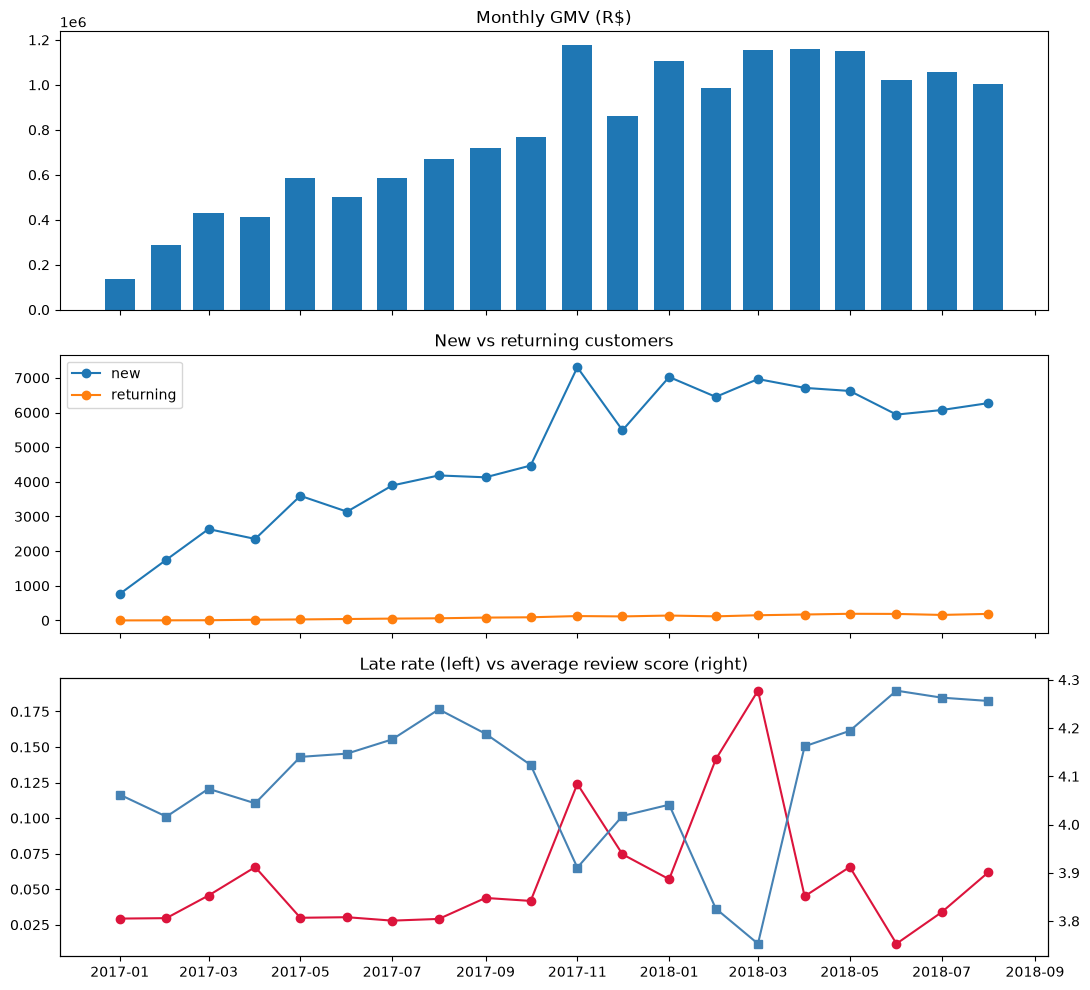

In [10]:
w = m[(m.order_month >= "2017-01-01") & (m.order_month <= "2018-08-01")].copy()
print(len(w), "months in window")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

ax[0].bar(w.order_month, w.gmv, width=20)
ax[0].set_title("Monthly GMV (R$)")

ax[1].plot(w.order_month, w.n_new_customers, marker="o", label="new")
ax[1].plot(w.order_month, w.n_returning_customers, marker="o", label="returning")
ax[1].set_title("New vs returning customers")
ax[1].legend()

ax[2].plot(w.order_month, w.late_rate, marker="o", color="crimson", label="late rate")
ax2 = ax[2].twinx()
ax2.plot(w.order_month, w.avg_review, marker="s", color="steelblue", label="avg review")
ax[2].set_title("Late rate (left) vs average review score (right)")

plt.tight_layout()
plt.show()

In [11]:
import os
os.makedirs("../docs/img", exist_ok=True)
fig.savefig("../docs/img/monthly_overview.png", dpi=150, bbox_inches="tight")

In [12]:
q("""
select
    is_late,
    count(*)                                         as n_orders,
    round(avg(review_score), 2)                      as avg_review,
    round(count(*) filter (where review_score <= 2) * 1.0
          / nullif(count(review_score), 0), 3)       as low_review_rate,
    round(count(*) filter (where review_score = 5) * 1.0
          / nullif(count(review_score), 0), 3)       as five_star_rate,
    round(avg(order_revenue), 2)                     as avg_revenue,
    round(avg(delivery_days), 1)                     as avg_delivery_days
from main_marts.fct_orders
where is_late is not null
  and purchased_at < '2018-09-01'
group by is_late
order by is_late
""")

,is_late,n_orders,avg_review,low_review_rate,five_star_rate,avg_revenue,avg_delivery_days
0,False,89941,4.2900,0.0930,0.6230,158.6400,10.9000
1,True,6535,2.2700,0.6240,0.1650,176.1200,33.9000


In [13]:
q("""
with ranked as (
    select
        c.customer_unique_id,
        o.is_late,
        o.review_score,
        row_number() over (partition by c.customer_unique_id
                           order by o.purchased_at, o.order_id) as rn
    from main_marts.fct_orders o
    join main_staging.stg_customers c on c.customer_id = o.customer_id
    where o.purchased_at < '2018-09-01'
),
first_order as (
    select * from ranked where rn = 1 and is_late is not null
)
select
    f.is_late,
    count(*)                                   as n_customers,
    count(*) filter (where d.is_repeat)        as n_returned,
    round(count(*) filter (where d.is_repeat) * 100.0 / count(*), 4) as repeat_rate
from first_order f
join main_marts.dim_customers d on d.customer_unique_id = f.customer_unique_id
group by f.is_late
order by f.is_late
""")

,is_late,n_customers,n_returned,repeat_rate
0,False,86909,2716,3.1251
1,True,6345,161,2.5374


In [14]:
from statsmodels.stats.proportion import proportions_ztest
z, p = proportions_ztest([2683, 194], [85662, 7592])
print(f"z={z:.2f}  p={p:.4f}")

z=2.79  p=0.0053


In [15]:
q("""
select
    case when delay_days <= 0      then 'on time'
         when delay_days <= 3      then '1-3 days late'
         when delay_days <= 7      then '4-7 days late'
         when delay_days <= 14     then '8-14 days late'
         else '15+ days late' end                 as lateness_band,
    count(*)                                      as n_orders,
    round(avg(review_score), 2)                   as avg_review
from main_marts.fct_orders
where delay_days is not null and purchased_at < '2018-09-01'
group by 1
order by min(delay_days)
""")

,lateness_band,n_orders,avg_review
0,on time,89941,4.2900
1,1-3 days late,1870,3.2900
2,4-7 days late,1802,2.1000
3,8-14 days late,1479,1.6700
4,15+ days late,1384,1.7200


In [16]:
q("""
select
    count(*) filter (where is_late)              as n_late,
    count(is_late)                               as n_known,
    round(count(*) filter (where is_late) * 1.0
          / count(is_late), 4)                   as late_rate,
    count(*) filter (where is_late and delay_days = 0) as should_be_zero
from main_marts.fct_orders
""")

,n_late,n_known,late_rate,should_be_zero
0,6535,96476,0.0677,0


In [17]:
q("""
select
    is_late,
    count(*)                                     as n_orders,
    round(avg(review_score), 2)                  as avg_review,
    round(count(*) filter (where review_score <= 2) * 1.0
          / nullif(count(review_score), 0), 3)   as low_review_rate
from main_marts.fct_orders
where is_late is not null and purchased_at < '2018-09-01'
group by is_late
order by is_late
""")

,is_late,n_orders,avg_review,low_review_rate
0,False,89941,4.2900,0.0930
1,True,6535,2.2700,0.6240


In [18]:
print("--- headline ---")
display(q("""
select count(*) filter (where is_late) as n_late,
       count(is_late) as n_known,
       round(count(*) filter (where is_late)*1.0/count(is_late), 4) as late_rate
from main_marts.fct_orders
"""))

print("--- two-group comparison ---")
display(q("""
select is_late,
       count(*) as n_orders,
       round(avg(review_score),2) as avg_review,
       round(count(*) filter (where review_score<=2)*1.0/nullif(count(review_score),0),3) as low_review_rate,
       round(count(*) filter (where review_score=5)*1.0/nullif(count(review_score),0),3) as five_star_rate,
       round(avg(delivery_days),1) as avg_delivery_days
from main_marts.fct_orders
where is_late is not null and purchased_at < '2018-09-01'
group by is_late order by is_late
"""))

print("--- monthly range ---")
display(q("""
select min(late_rate) as min_rate, max(late_rate) as max_rate
from main_marts.fct_monthly
where order_month between '2017-01-01' and '2018-08-01'
"""))

print("--- seller average (the unweighted one) ---")
display(q("select round(avg(late_rate),4) as seller_avg_late_rate from main_marts.dim_sellers"))

print("--- repeat rate by first-order lateness ---")
display(q("""
with ranked as (
    select c.customer_unique_id, o.is_late,
           row_number() over (partition by c.customer_unique_id
                              order by o.purchased_at, o.order_id) as rn
    from main_marts.fct_orders o
    join main_staging.stg_customers c on c.customer_id = o.customer_id
    where o.purchased_at < '2018-09-01'
)
select f.is_late, count(*) as n_customers,
       count(*) filter (where d.is_repeat) as n_returned,
       round(count(*) filter (where d.is_repeat)*100.0/count(*), 4) as repeat_rate
from ranked f
join main_marts.dim_customers d on d.customer_unique_id = f.customer_unique_id
where f.rn = 1 and f.is_late is not null
group by f.is_late order by f.is_late
"""))

--- headline ---


,n_late,n_known,late_rate
0,6535,96476,0.0677


--- two-group comparison ---


,is_late,n_orders,avg_review,low_review_rate,five_star_rate,avg_delivery_days
0,False,89941,4.2900,0.0930,0.6230,10.9000
1,True,6535,2.2700,0.6240,0.1650,33.9000


--- monthly range ---


,min_rate,max_rate
0,0.0116,0.1896


--- seller average (the unweighted one) ---


,seller_avg_late_rate
0,0.0691


--- repeat rate by first-order lateness ---


,is_late,n_customers,n_returned,repeat_rate
0,False,86909,2716,3.1251
1,True,6345,161,2.5374


In [19]:
q("select round(avg(late_rate), 4) as seller_avg, round(count(*) filter (where is_late)*1.0/count(is_late),4) as x from main_marts.dim_sellers, main_marts.fct_orders limit 1")

,seller_avg,x
0,0.0691,0.0677


In [20]:
q("select round(avg(late_rate), 4) as seller_avg_late_rate from main_marts.dim_sellers")

,seller_avg_late_rate
0,0.0691


In [27]:
c = q("select * from main_marts.fct_cohort_retention order by cohort_month, month_number")
print(len(c), "rows          (expect 210)")
print(c.cohort_month.nunique(), "cohorts        (expect 20)")
print("month 0 retention values:", c[c.month_number == 0].retention.unique(), " (expect [1.])")
print("max retention:", c.retention.max(), " (must be <= 1.0)")

210 rows          (expect 210)
20 cohorts        (expect 20)
month 0 retention values: [1.]  (expect [1.])
max retention: 1.0  (must be <= 1.0)


In [28]:
sizes = c.groupby("cohort_month").cohort_size.first()
print(sizes.sum(), "customers total")     # ~93,000
print(sizes.mean().round(0), "avg cohort size")
print(sizes.min(), "smallest,", sizes.max(), "largest")

95764 customers total
4788.0 avg cohort size
764 smallest, 7304 largest


In [29]:
c.groupby("cohort_month").size()

cohort_month
2017-01-01    20
2017-02-01    19
2017-03-01    18
2017-04-01    17
2017-05-01    16
2017-06-01    15
2017-07-01    14
2017-08-01    13
2017-09-01    12
2017-10-01    11
2017-11-01    10
2017-12-01     9
2018-01-01     8
2018-02-01     7
2018-03-01     6
2018-04-01     5
2018-05-01     4
2018-06-01     3
2018-07-01     2
2018-08-01     1
dtype: int64

In [31]:
c

,cohort_month,month_number,cohort_size,n_active,retention
0,2017-01-01,0,764,764,1.0000
1,2017-01-01,1,764,3,0.0039
2,2017-01-01,2,764,2,0.0026
3,2017-01-01,3,764,1,0.0013
4,2017-01-01,4,764,3,0.0039
...,...,...,...,...,...
205,2018-06-01,1,5940,25,0.0042
206,2018-06-01,2,5940,17,0.0029
207,2018-07-01,0,6071,6071,1.0000
208,2018-07-01,1,6071,44,0.0072


In [30]:
piv = c.pivot(index="cohort_month", columns="month_number", values="retention")
(piv * 100).round(2)

month_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
cohort_month,,,,,,,,,,,,,,,,,,,,
2017-01-01,100.0000,0.3900,0.2600,0.1300,0.3900,0.1300,0.5200,0.1300,0.1300,0.0000,0.3900,0.1300,0.7900,0.3900,0.1300,0.1300,0.2600,0.3900,0.0000,0.1300
2017-02-01,100.0000,0.2300,0.2900,0.1100,0.4000,0.1100,0.2300,0.1700,0.1700,0.2300,0.1100,0.2900,0.1700,0.1700,0.1100,0.0600,0.0600,0.2300,0.0000,NaN
2017-03-01,100.0000,0.4900,0.3800,0.3800,0.3400,0.1500,0.1500,0.3000,0.3400,0.0800,0.3800,0.1500,0.2300,0.1100,0.1500,0.2300,0.0800,0.1500,NaN,NaN
2017-04-01,100.0000,0.6000,0.2100,0.1700,0.3400,0.2600,0.3400,0.3000,0.3000,0.1700,0.2600,0.0900,0.0900,0.0400,0.0900,0.0900,0.2100,NaN,NaN,NaN
2017-05-01,100.0000,0.5000,0.5000,0.3900,0.3100,0.3300,0.4200,0.1700,0.2500,0.3100,0.2500,0.3300,0.2500,0.0300,0.1900,0.2500,NaN,NaN,NaN,NaN
2017-06-01,100.0000,0.4800,0.3500,0.4100,0.2500,0.3800,0.3800,0.2200,0.1300,0.2200,0.3200,0.3500,0.1600,0.1300,0.1900,NaN,NaN,NaN,NaN,NaN
2017-07-01,100.0000,0.5100,0.3600,0.2600,0.2800,0.2100,0.3100,0.1000,0.1800,0.2600,0.2300,0.3100,0.1300,0.2600,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-01,100.0000,0.6900,0.3300,0.2600,0.3600,0.5300,0.2900,0.2600,0.1400,0.1400,0.2400,0.1900,0.1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,100.0000,0.6800,0.5300,0.2900,0.4600,0.2200,0.2200,0.2400,0.2900,0.1700,0.2700,0.0700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


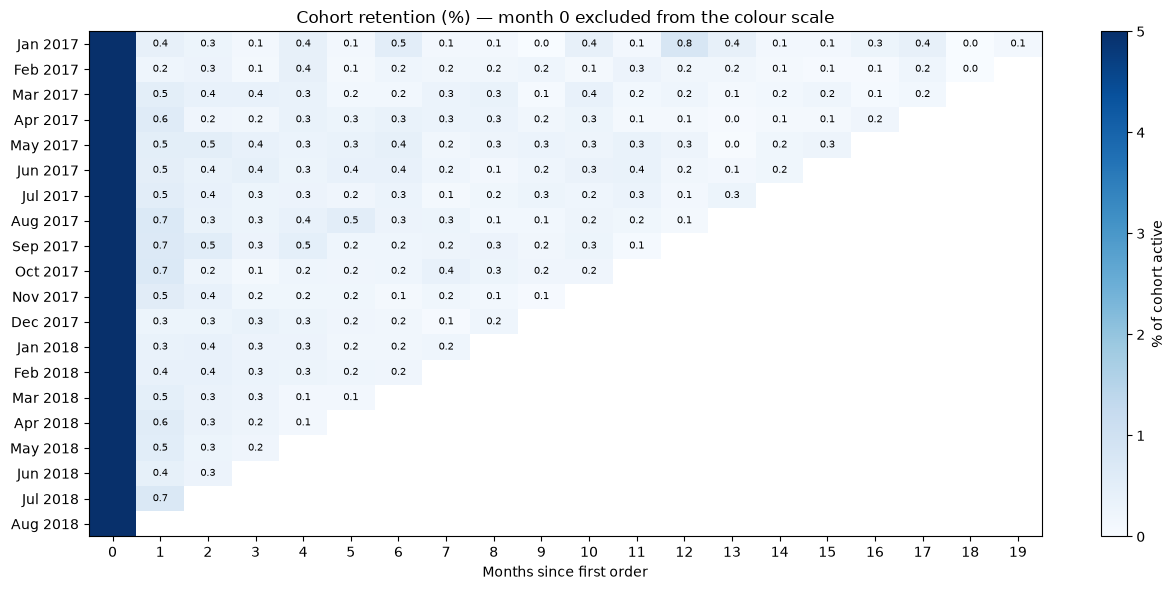

In [32]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(piv.values * 100, cmap="Blues", aspect="auto", vmin=0, vmax=5)

ax.set_xticks(range(len(piv.columns)))
ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)))
ax.set_yticklabels([d.strftime("%b %Y") for d in piv.index])
ax.set_xlabel("Months since first order")
ax.set_title("Cohort retention (%) — month 0 excluded from the colour scale")

for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if not np.isnan(v) and j > 0:
            ax.text(j, i, f"{v*100:.1f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, label="% of cohort active")
plt.tight_layout()
fig.savefig("../docs/img/cohort_retention.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
c[(c.cohort_month == "2017-01-01")][["month_number", "n_active", "cohort_size", "retention"]]

,month_number,n_active,cohort_size,retention
0,0,764,764,1.0000
1,1,3,764,0.0039
2,2,2,764,0.0026
3,3,1,764,0.0013
4,4,3,764,0.0039
5,5,1,764,0.0013
6,6,4,764,0.0052
7,7,1,764,0.0013
8,8,1,764,0.0013
9,9,0,764,0.0000


In [ ]:
#The average retention curve, volume-weighted (not the mean of the percentages)
curve = (c[c.month_number > 0]
         .groupby("month_number")
         .apply(lambda g: g.n_active.sum() / g.cohort_size.sum()))
print((curve * 100).round(2))

#What fraction of a cohort EVER comes back within its observable window
ever = (c[c.month_number > 0]
        .groupby("cohort_month")
        .apply(lambda g: g.n_active.sum() / g.cohort_size.iloc[0]))
print((ever * 100).round(2))

month_number
1    0.5100
2    0.3400
3    0.2600
4    0.2600
5    0.2200
6    0.2300
7    0.2100
8    0.2100
9    0.1700
10   0.2600
11   0.2200
12   0.1800
13   0.1400
14   0.1500
15   0.1700
16   0.1300
17   0.2100
18   0.0000
19   0.1300
dtype: float64
cohort_month
2017-01-01   4.8400
2017-02-01   3.1400
2017-03-01   4.1000
2017-04-01   3.5300
2017-05-01   4.4800
2017-06-01   3.9800
2017-07-01   3.3900
2017-08-01   3.5400
2017-09-01   3.4400
2017-10-01   2.7100
2017-11-01   1.9700
2017-12-01   1.7900
2018-01-01   1.8500
2018-02-01   1.7500
2018-03-01   1.3200
2018-04-01   1.2700
2018-05-01   1.0100
2018-06-01   0.7100
2018-07-01   0.7200
dtype: float64


In [35]:
K = 3   # returned within 3 months

sub = c[(c.month_number > 0) & (c.month_number <= K)]
# keep only cohorts old enough to have K months observed
complete = sub.groupby("cohort_month").month_number.max()
valid = complete[complete == K].index

ret_k = (sub[sub.cohort_month.isin(valid)]
         .groupby("cohort_month")
         .apply(lambda g: g.n_active.sum() / g.cohort_size.iloc[0]))
print((ret_k * 100).round(2))

cohort_month
2017-01-01   0.7900
2017-02-01   0.6300
2017-03-01   1.2500
2017-04-01   0.9800
2017-05-01   1.3900
2017-06-01   1.2400
2017-07-01   1.1300
2017-08-01   1.2900
2017-09-01   1.5000
2017-10-01   1.0300
2017-11-01   1.1100
2017-12-01   0.8700
2018-01-01   1.0100
2018-02-01   1.0700
2018-03-01   1.0600
2018-04-01   1.1300
2018-05-01   1.0100
dtype: float64
